# Multi-Class Migraine Severity Classification

This notebook extends the project beyond binary migraine occurrence prediction by modelling `migraine_severity` as a multi-class target. It follows the supervisor suggestion to test additional classifiers, including SVM, and it evaluates whether the improved feature set can distinguish severity levels.

## 1. Import required libraries

The libraries below support data loading, feature engineering, model training, and multi-class evaluation.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')


## 2. Load the dataset

The dataset is loaded from the project data folder using an absolute path so the notebook runs reliably in this environment.

In [2]:
data_path = Path('/Users/cioran/Documents/migraine-prediction-project/data/migraine_dataset.csv')
print('Loading dataset from:', data_path)
df = pd.read_csv(data_path)
df.head()


Loading dataset from: /Users/cioran/Documents/migraine-prediction-project/data/migraine_dataset.csv


,user_id,date,sleep_hours,mood_level,stress_level,hydration_level,screen_time,migraine_occurrence,migraine_severity
0,1,1/15/2024,7.8,3,2,2,4.7,1,1
1,1,1/16/2024,6.6,4,1,2,3.2,1,1
2,1,1/17/2024,8.5,4,2,2,4.7,1,2
3,1,1/18/2024,7.5,3,2,3,3.8,1,3
4,1,1/19/2024,9.0,3,2,1,6.8,1,2


## 3. Create the improved feature set

The same improved features used in the best binary model are created here so that severity classification can be compared on a similar basis.

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['sleep_stress_interaction'] = df['sleep_hours'] * df['stress_level']
df['screen_stress_interaction'] = df['screen_time'] * df['stress_level']
df['hydration_stress_interaction'] = df['hydration_level'] * df['stress_level']

features = [
    'sleep_hours',
    'mood_level',
    'stress_level',
    'hydration_level',
    'screen_time',
    'day_of_week',
    'month',
    'sleep_stress_interaction',
    'screen_stress_interaction',
    'hydration_stress_interaction',
]

X = df[features]
print('Feature matrix shape:', X.shape)
print('Severity distribution:')
print(df['migraine_severity'].value_counts().sort_index())


Feature matrix shape: (11879, 10)
Severity distribution:
migraine_severity
0    6119
1    2493
2    2874
3     393
Name: count, dtype: int64


## 4. Acknowledge the severity-label limitation

The public Kaggle description confirms that `migraine_severity` exists, but it does not clearly explain how that score was obtained. This means the severity target should be treated carefully and discussed as a limitation in the dissertation.

In [4]:
severity_crosstab = pd.crosstab(df['migraine_occurrence'], df['migraine_severity'])
print('Cross-tabulation of occurrence against severity:')
print(severity_crosstab)

if (severity_crosstab.loc[0, 1:].sum() == 0) and (severity_crosstab.loc[1, 0] == 0):
    print('Observation: severity is perfectly nested inside occurrence in this dataset.')

Cross-tabulation of occurrence against severity:
migraine_severity       0     1     2    3
migraine_occurrence                       
0                    6119     0     0    0
1                       0  2493  2874  393
Observation: severity is perfectly nested inside occurrence in this dataset.


## 5. Define the multi-class target

The first severity experiment uses the full four-class target (`0`, `1`, `2`, `3`). This means the model must separate no migraine from increasing severity levels.

In [5]:
y = df['migraine_severity']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (9503, 10)
Testing shape: (2376, 10)


## 6. Train Logistic Regression, Random Forest, Gradient Boosting, and SVM

The notebook compares four models. SVM is included in direct response to the supervisor recommendation.

In [6]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced_subsample'
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', CalibratedClassifierCV(SVC(random_state=42), method='sigmoid', cv=3))
    ]),
}

results = []
reports = {}
confusions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, predictions, average='macro', zero_division=0
    )
    roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Macro Precision': precision,
        'Macro Recall': recall,
        'Macro F1': f1,
        'Macro ROC-AUC': roc_auc,
    })

    reports[name] = classification_report(y_test, predictions, zero_division=0)
    confusions[name] = confusion_matrix(y_test, predictions)
    probabilities[name] = proba

comparison_df = pd.DataFrame(results).sort_values(
    by=['Macro ROC-AUC', 'Macro F1'], ascending=False
).reset_index(drop=True)
comparison_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC
0,Gradient Boosting,0.522306,0.446722,0.307636,0.284377,0.685128
1,Logistic Regression,0.502946,0.219725,0.274046,0.233537,0.675672
2,Random Forest,0.481061,0.350237,0.301662,0.298098,0.643622
3,SVM,0.510522,0.218582,0.265735,0.216898,0.587702


## 7. Review model comparison

The table below shows the relative performance of the four classifiers using multi-class metrics.

In [7]:
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC
0,Gradient Boosting,0.522306,0.446722,0.307636,0.284377,0.685128
1,Logistic Regression,0.502946,0.219725,0.274046,0.233537,0.675672
2,Random Forest,0.481061,0.350237,0.301662,0.298098,0.643622
3,SVM,0.510522,0.218582,0.265735,0.216898,0.587702


## 8. Inspect the best model in more detail

A classification report and confusion matrix help show which severity classes are easier or harder to distinguish.

In [8]:
best_model_name = comparison_df.loc[0, 'Model']
print('Best multi-class model:', best_model_name)
print('\nClassification report:\n')
print(reports[best_model_name])
print('Confusion matrix:\n')
print(confusions[best_model_name])

Best multi-class model: Gradient Boosting

Classification report:

              precision    recall  f1-score   support

           0       0.55      0.87      0.68      1224
           1       0.21      0.01      0.01       499
           2       0.40      0.29      0.33       575
           3       0.62      0.06      0.12        78

    accuracy                           0.52      2376
   macro avg       0.45      0.31      0.28      2376
weighted avg       0.45      0.52      0.44      2376

Confusion matrix:

[[1067    6  150    1]
 [ 431    3   65    0]
 [ 402    5  166    2]
 [  35    0   38    5]]


## 9. Plot the confusion matrix for the best model

This visual summary helps show where misclassification is concentrated.

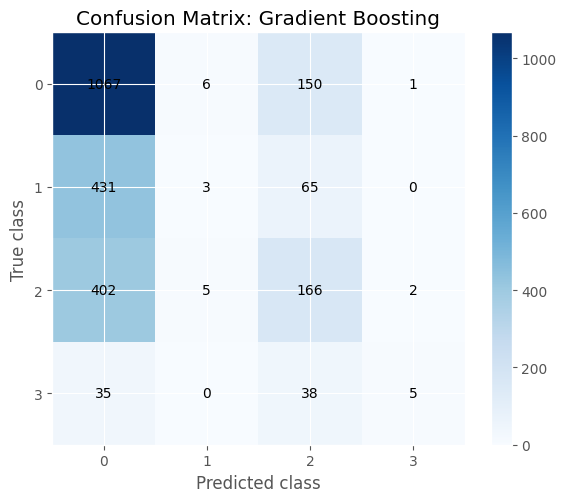

In [9]:
best_confusion = confusions[best_model_name]
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(best_confusion, cmap='Blues')
ax.set_title(f'Confusion Matrix: {best_model_name}')
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
for i in range(best_confusion.shape[0]):
    for j in range(best_confusion.shape[1]):
        ax.text(j, i, best_confusion[i, j], ha='center', va='center', color='black')
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## 10. Conclusion

This notebook addresses the supervisor request to test a multi-class classifier, including SVM. In the current dataset, `migraine_severity` is harder to predict accurately than binary occurrence, and the severity label should be interpreted cautiously because its public construction is not clearly documented.